# Modeling: Top-k Profit Curve

Run after `feature_selection.ipynb`. Outputs → `outputs/topk_profit_curve/`.


## Flow

1. `setup_modeling_notebook` — style + data
2. Compare models → HPO → OOF curves
3. Export test submission


In [1]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
from cost_effective.models import compute_oof_probabilities
from cost_effective.notebook_setup import setup_modeling_notebook
from cost_effective.notebook_workflows import (
    build_estimator_factories,
    evaluate_topk_oof,
    export_topk_test_predictions,
    run_model_comparison,
    save_tuned_comparison,
    select_winner_from_candidates,
    stage_matrices,
    tune_winner,
)
from cost_effective.paths import APPROACH_TOPK_PROFIT_CURVE
from cost_effective.plots import plot_topk_oof_profit_curve

In [3]:
ctx = setup_modeling_notebook(APPROACH_TOPK_PROFIT_CURVE)
_, y_train, x_test, x_stage2 = stage_matrices(ctx)
feature_sets = ctx.stage.feature_set_candidates
ctx.stage.stage3_scores.head()

,feature_set_name,feature_count,cv_score_mean,cv_score_std,f1_score,roc_auc_score,business_score_no_var_penalty,features
0,top_01,1,2301.0,24.779023,0.667868,0.547226,2501.0,[var_389]
1,top_03,3,1891.0,32.155870,0.666970,0.550985,2491.0,"[var_389, var_308, var_93]"
2,top_05,5,1490.0,23.874673,0.666908,0.589741,2490.0,"[var_389, var_308, var_93, var_87, var_254]"
3,top_08,8,898.0,30.757113,0.667579,0.583463,2498.0,"[var_389, var_308, var_93, var_87, var_254, va..."
4,top_10,10,486.0,17.146428,0.666538,0.616666,2486.0,"[var_389, var_308, var_93, var_87, var_254, va..."


In [4]:
comparison_base = run_model_comparison(ctx, estimator_factories=build_estimator_factories(ctx))
comparison_base.to_csv(ctx.outputs_path / "model_comparison_base.csv", index=False)

winner = select_winner_from_candidates(comparison_base, feature_sets)
x_best = x_stage2[winner.features]

winner

WinnerSelection(model_name='logistic_regression', feature_set_name='top_01', features=['var_389'], cv_score_mean=2306.0)

In [5]:
best_est, best_params, hpo_cv, tuned_factory = tune_winner(
    ctx, winner, build_estimator_factories(ctx)[winner.model_name], x_best
)

comparison = save_tuned_comparison(ctx, winner, tuned_factory, best_params)
comparison.sort_values("cv_score_mean", ascending=False).head(10)

,model_name,feature_set_name,feature_count,cv_score_mean,cv_score_std,f1_score,roc_auc_score,business_score_no_var_penalty,best_hyperparams
0,logistic_regression,top_01,1,2306.0,20.34699,0.668303,0.555137,2506.0,"{""logisticregression__C"": 0.001, ""logisticregr..."


In [6]:
oof_probabilities = compute_oof_probabilities(
    x_best, y_train, estimator_factory=tuned_factory, cv=5
)

oof_eval = evaluate_topk_oof(
    y_train, oof_probabilities, len(winner.features), max_targets=ctx.max_targets
)
for line in oof_eval.summary_lines:
    print(line)
oof_eval.confusion_matrix

Business-optimal: k=997, threshold=0.5201, score=3290.00
F1-optimal: k=1000, threshold=0.5201, f1=0.3245, roc_auc=0.5543, avg_precision=0.5476
Business curve TP=565, FP=432
F1 curve TP=566, FP=434
OOF profit-optimal k=997, break-even k=1000, effective k=997


,Predicted 0,Predicted 1
Actual 0,2080,432
Actual 1,1923,565


In [7]:
oof_eval.f1_curve.curve.head(10)

,k,tp,fp,fn,tn,precision,recall,f1,accuracy,specificity,threshold
0,1,1,0,2487,2512,1.000000,0.000402,0.000804,0.5026,1.000000,0.722041
1,2,2,0,2486,2512,1.000000,0.000804,0.001606,0.5028,1.000000,0.719853
2,3,3,0,2485,2512,1.000000,0.001206,0.002409,0.5030,1.000000,0.719210
3,4,3,1,2485,2511,0.750000,0.001206,0.002408,0.5028,0.999602,0.712627
4,5,3,2,2485,2510,0.600000,0.001206,0.002407,0.5026,0.999204,0.703820
5,6,4,2,2484,2510,0.666667,0.001608,0.003208,0.5028,0.999204,0.701937
6,7,5,2,2483,2510,0.714286,0.002010,0.004008,0.5030,0.999204,0.672196
7,8,6,2,2482,2510,0.750000,0.002412,0.004808,0.5032,0.999204,0.667248
8,9,6,3,2482,2509,0.666667,0.002412,0.004806,0.5030,0.998806,0.662091
9,10,7,3,2481,2509,0.700000,0.002814,0.005604,0.5032,0.998806,0.660982


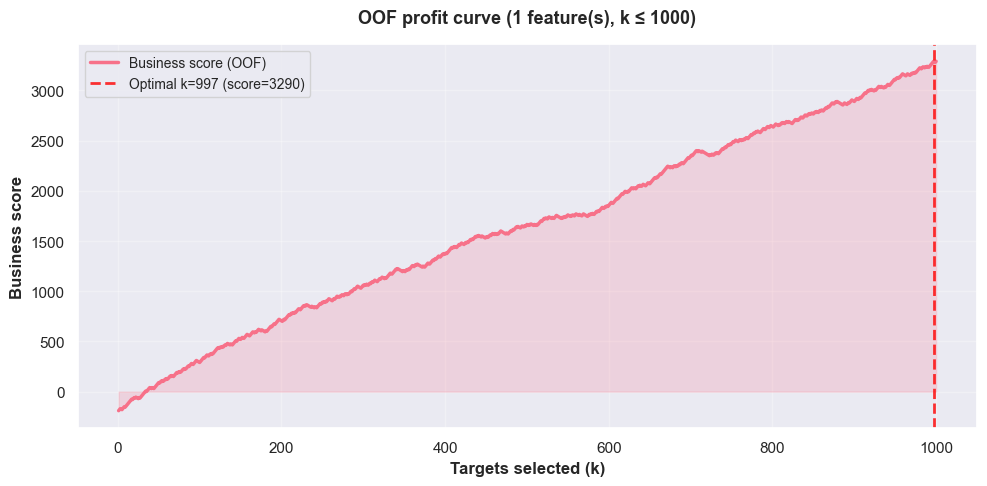

In [8]:
plot_topk_oof_profit_curve(
    oof_eval.business_curve,
    feature_count=len(winner.features),
    max_targets=ctx.max_targets,
).show()

In [9]:
predictions = export_topk_test_predictions(
    ctx,
    winner,
    x_stage2,
    y_train,
    x_test,
    tuned_factory,
    oof_eval.optimal_k,
    cv_business_mean=winner.cv_score_mean,
    hpo_cv=hpo_cv,
    oof_eval=oof_eval,
)
predictions.head()

,rank,sample_index,probability
0,1,4134,0.735428
1,2,1691,0.721564
2,3,2916,0.714486
3,4,4403,0.693772
4,5,588,0.687017
